# Demand Forecasting Tool for a Nonprofit Organization
### Member 2 — Individual Contributor | Tool: Matplotlib / Seaborn
**SDC Internship — Group 17** | Group Lead: Areeba Rasool

**Dataset:** Blood Transfusion Service Center (UCI Machine Learning Repository) — donor recency, frequency, monetary value, and time-since-first-donation for 748 blood donors, along with whether they donated again in March 2007.

**Note on data version:** This notebook uses the full `transfusion.csv` as shared by the Group Lead, with no rows removed, so that findings stay consistent with the rest of the team's analysis.

---

### Mini-Plan
My piece of the group project focuses on visually exploring donor behavior patterns using Matplotlib/Seaborn — specifically how recency, frequency, and monetary value of past donations relate to whether a donor returns to donate again. I will document the dataset, build 3 labeled charts (a correlation heatmap, a recency comparison, and a frequency distribution), and turn the patterns I find into one clear, actionable recommendation the nonprofit can use to plan its next blood donation drive.

## 1. Setup & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("transfusion.csv")
df.columns = ["Recency", "Frequency", "Monetary", "Time", "Class"]
df.head()

,Recency,Frequency,Monetary,Time,Class
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


**Column meanings:**
- `Recency` — months since the donor's last donation
- `Frequency` — total number of times the donor has donated
- `Monetary` — total blood donated, in c.c. (directly proportional to Frequency)
- `Time` — months since the donor's first donation
- `Class` — 1 if the donor gave blood again in March 2007, 0 if not (this is what a nonprofit would want to predict/plan around)

## 2. Document & Check the Dataset

In [2]:
# Check for missing values and dataset shape
print("Missing values per column:\n", df.isnull().sum())
print("\nShape:", df.shape)
df.describe()

Missing values per column:
 Recency      0
Frequency    0
Monetary     0
Time         0
Class        0
dtype: int64

Shape: (748, 5)


,Recency,Frequency,Monetary,Time,Class
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968
std,8.095396,5.839307,1459.826781,24.376714,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


We keep the full dataset as shared by the Group Lead (no rows dropped) so that every group member's numbers are calculated on the exact same data — important since we're all analyzing different slices of the same donor base.

## 3. Early Observations (EDA)

In [3]:
donation_rate = df['Class'].mean() * 100
print(f"Overall repeat-donation rate: {donation_rate:.1f}%")
print(f"Average recency: {df['Recency'].mean():.1f} months")
print(f"Average frequency: {df['Frequency'].mean():.1f} past donations")
print("\nCorrelation of each metric with repeat donation (Class):")
print(df.corr(numeric_only=True)['Class'].sort_values(ascending=False))

Overall repeat-donation rate: 23.8%
Average recency: 9.5 months
Average frequency: 5.5 past donations

Correlation of each metric with repeat donation (Class):
Class        1.000000
Monetary     0.218633
Frequency    0.218633
Time        -0.035854
Recency     -0.279869
Name: Class, dtype: float64


In [4]:
# Key team findings, verified on this dataset
recent = df[df['Recency'] <= 6]
older = df[df['Recency'] > 6]
one_time = df[df['Frequency'] == 1]

print(f"Donors active in last 0-6 months -> return rate: {recent['Class'].mean()*100:.1f}%")
print(f"Donors inactive 6+ months        -> return rate: {older['Class'].mean()*100:.1f}%")
print(f"One-time donors (Frequency=1)    -> did NOT return: {(1 - one_time['Class'].mean())*100:.1f}%")

Donors active in last 0-6 months -> return rate: 37.3%
Donors inactive 6+ months        -> return rate: 10.8%
One-time donors (Frequency=1)    -> did NOT return: 87.3%


**Early observations (matching Group Lead's shared findings):**
1. Only about **24% of donors** gave blood again in March 2007 — most donors are one-time or infrequent.
2. **Recency is the strongest driver** of repeat donation: donors active in the last 0-6 months return at **~37%**, versus only **~11%** for donors inactive 6+ months.
3. **87% of one-time donors never return** — a huge drop-off after the first donation.
4. Frequency and Monetary move together perfectly (they measure the same thing — total blood given), with a mild positive relationship with returning.

## 4. Chart 1 — Correlation Heatmap

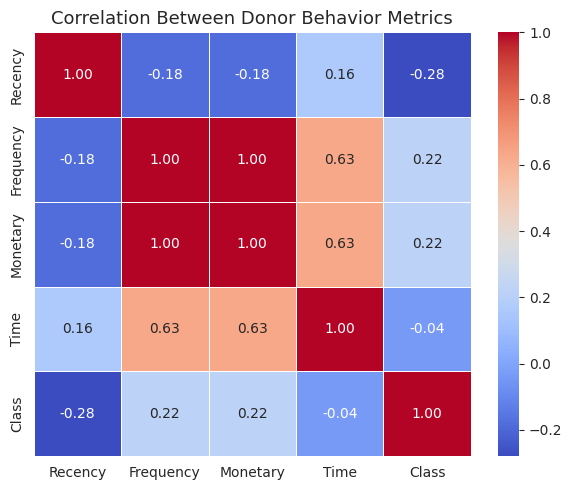

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Donor Behavior Metrics", fontsize=13)
plt.tight_layout()
plt.savefig("chart1_correlation_heatmap.png", dpi=120)
plt.show()

## 5. Chart 2 — Recency: Donors vs. Non-Donors

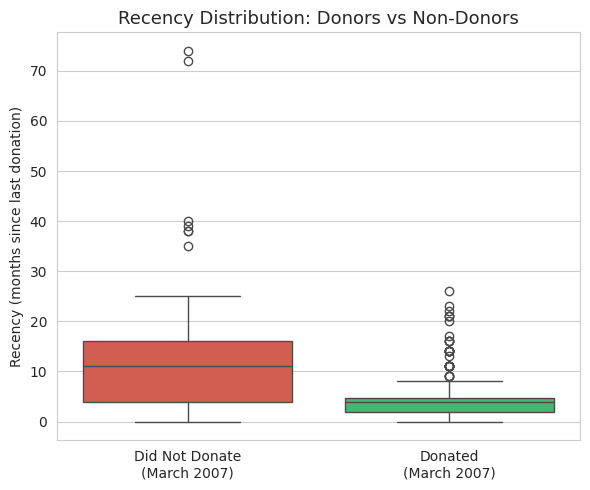

In [6]:
plt.figure(figsize=(6, 5))
sns.boxplot(x="Class", y="Recency", data=df, hue="Class",
            palette=["#e74c3c", "#2ecc71"], legend=False)
plt.xticks([0, 1], ["Did Not Donate\n(March 2007)", "Donated\n(March 2007)"])
plt.ylabel("Recency (months since last donation)")
plt.xlabel("")
plt.title("Recency Distribution: Donors vs Non-Donors", fontsize=13)
plt.tight_layout()
plt.savefig("chart2_recency_boxplot.png", dpi=120)
plt.show()

## 6. Chart 3 — Return Rate by Recency Bucket

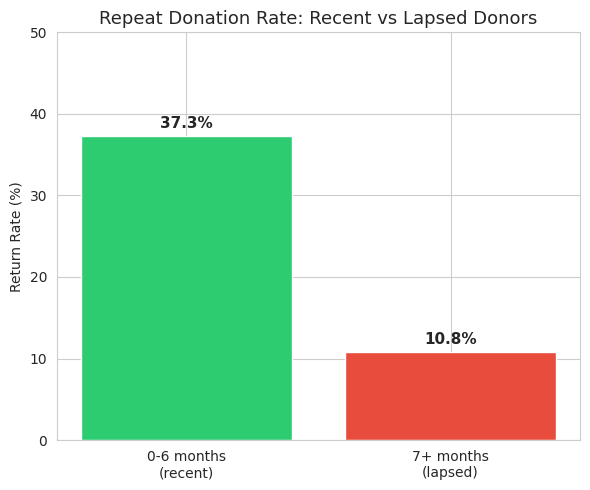

In [7]:
bucket_labels = ["0-6 months\n(recent)", "7+ months\n(lapsed)"]
return_rates = [recent['Class'].mean()*100, older['Class'].mean()*100]

plt.figure(figsize=(6, 5))
bars = plt.bar(bucket_labels, return_rates, color=["#2ecc71", "#e74c3c"])
plt.ylabel("Return Rate (%)")
plt.title("Repeat Donation Rate: Recent vs Lapsed Donors", fontsize=13)
for bar, rate in zip(bars, return_rates):
    plt.text(bar.get_x() + bar.get_width()/2, rate + 1, f"{rate:.1f}%",
              ha="center", fontsize=11, fontweight="bold")
plt.ylim(0, 50)
plt.tight_layout()
plt.savefig("chart3_return_rate_by_recency.png", dpi=120)
plt.show()

## 7. What the Data Shows (Plain Language)

The charts show a clear pattern: **how recently someone last donated blood is the single best signal for whether they'll donate again**, more so than how many times they've donated in total. The correlation heatmap confirms Recency has the strongest link to repeat donation. The boxplot shows donors who returned in March 2007 typically gave blood much more recently than non-returning donors. The bar chart makes the gap concrete: donors active in the last 0-6 months return about **37%** of the time, versus roughly **11%** for donors inactive longer than that — and a striking **87% of one-time donors never come back** at all.

## 8. Insight-Driven Recommendation

**Recommendation:** The nonprofit should prioritize its outreach budget on donors who gave blood within the last 0-6 months rather than spreading effort evenly across the whole donor list. A targeted reminder campaign (call/SMS/email) sent to this "recently active" segment is likely to yield a meaningfully higher response rate (~37%) than reaching lapsed donors (~11%), since recency — not total donation history — is what most separates returning donors from lapsed ones. Because 87% of one-time donors never return, the nonprofit should also build a dedicated "second-donation" follow-up message aimed specifically at first-time donors shortly after their first visit, since that's the point where most drop-off happens.

---
### Tool & Workflow Notes
- **Tool used:** Python (pandas for exploration, Matplotlib/Seaborn for visualization) inside Jupyter Notebook.
- **Dataset source:** UCI Machine Learning Repository — Blood Transfusion Service Center Data Set (shared by Group Lead, Areeba Rasool), used in full/unmodified form to keep results consistent with the rest of Group 17.
- **Reproducibility:** Running all cells top-to-bottom regenerates all three chart PNGs directly from `transfusion.csv`.